# Colors in scientific graphics

Do you know someone with color vision defficiency? if you have 10 male friends, there is about **57% chance that at least one of them is colorblind**. Around 8% of men and 0.5% of women have some form of color vision deficiency, and journals frequently reproduce figures in grayscale. The wrong palette can obscure patterns, mislead readers, or make a figure unreadable for a significant fraction of your audience.  

A figure that fails either test is a figure that communicates less than it should. This notebook builds the practical skills needed to make more inclusive and defensible color choices. It starts from matplotlib's global plotting settings and works through a progression of palette strategies: the built-in colorblind-safe styles (tableau-colorblind10, seaborn-v0_8-colorblind), algorithmic generation of maximally distinct colors with distinctipy, sampling continuous colormaps (cividis, turbo, Tol's sunset) to produce discrete palettes, and curated hand-picked rainbow sequences from Krzywinski and Tol that span the full visible spectrum while remaining distinguishable under color vision deficiency. The notebook then closes the loop by simulating how each palette actually looks under nine different colorblindness models and under the grayscale luminosity transform, giving you a concrete way to test your choices before submitting a figure.



https://www.youtube.com/watch?v=LCaGxUdiPUI

https://www.youtube.com/watch?v=GHVGW2EzgUo

https://www.youtube.com/watch?v=9m8dKcM-cVI

https://drive.google.com/drive/folders/1hLy5b_O30d3KrABuw--EwG0x7-70jYZD?usp=sharing

Welcome! Today's focus is on colors and scientific plotting, which will serve as a foundation for future notebooks. Let's begin by installing our necessary software and packages, including `distinctipy`, which helps generate visually distinct colors for our plots.

In [ ]:
######################################################
##-install the necessery packages for this tutorial-##
######################################################

%%capture
!pip install distinctipy ##-see https://distinctipy.readthedocs.io/en/latest/
!pip install opencv-python ##-see https://docs.opencv.org/4.x/
!pip install tol-colors ##-see https://sronpersonalpages.nl/~pault

Import libraries

In [ ]:
#########################
##-Importing libraries-##
#########################

import cv2
import distinctipy as dis
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import pandas as pd
import seaborn as sns
import tol_colors as tc

The easier a graph is to read, the better. While 3D plots might look fancy, they often make data harder to interpret. In this cell, we will practice simplifying complex data into 2D projections or color-coded tables to make the information immediately clear.

In [ ]:
#######################
##-Plotting settings-##
#######################

l = 8.25/2.54 ##-inches
plt.rc('figure',figsize=(l,l)) ##-figure size
plt.rc('figure',      dpi=100) ##-figure dpi
plt.rc('lines',  linewidth=4) ##-linewidth
plt.rc('font',        size=10) ##-fontsize of the text
plt.rc('font', family='sans-serif') ##-font family
plt.rc('axes',   titlesize=10) ##-fontsize of the axes title
plt.rc('axes',   labelsize=9) ##-fontsize of the x and y labels
plt.rc('xtick',  labelsize=8) ##-fontsize of the tick labels
plt.rc('ytick',  labelsize=8) ##-fontsize of the tick labels
plt.rc('legend', fontsize =8) ##-fontsize of the legend
plt.rc('figure', titlesize=10) ##-fontsize of the figure title

## Choosing colormaps

Make a lot with default settings.

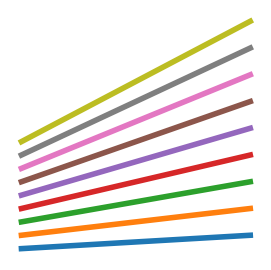

In [ ]:
plt.figure()
x = np.linspace(0, 1, 10)

for i in range(1, 10):
  plt.plot(x, i*x+i)

plt.axis('off')

plt.show()

Redefine the default color palette to colorblind safe.

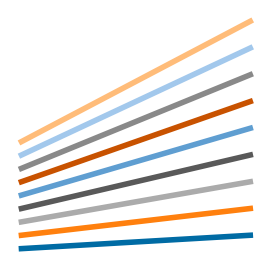

In [ ]:
##-Use tableau-colorblind10 palette
plt.style.use('tableau-colorblind10')

plt.figure()
x = np.linspace(0, 1, 10)

for i in range(1, 10):
  plt.plot(x, i*x+i)

plt.axis('off')

plt.show()

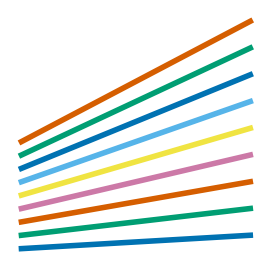

In [ ]:
##-Use seaborn-colorblind palette
plt.style.use('seaborn-v0_8-colorblind')

plt.figure()
x = np.linspace(0, 1, 10)

for i in range(1, 10):
  plt.plot(x, i*x+i)

plt.axis('off')

plt.show()

Plot the same but with seaborn. Note that the order is not the same.

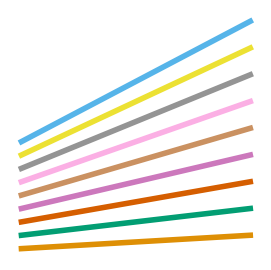

In [ ]:
##-Use seaborn
colors = sns.color_palette('colorblind', 10).as_hex()

plt.figure()
x = np.linspace(0, 1, 10)

for i in range(1, 10):
  plt.plot(x, i*x+i, color=colors[i])

plt.axis('off')

plt.show()

Use distinctipy. Note that each call for get_colors gives different set of colors.

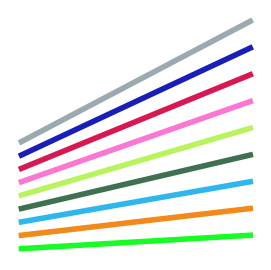

In [ ]:
##-Use distinctipy
colors = dis.get_colors(10, pastel_factor=0.1)

plt.figure()
x = np.linspace(0, 1, 10)

for i in range(1, 10):
  plt.plot(x, i*x+i,color=colors[i])

plt.axis('off')

plt.show()

Turn any matplotlib map into a palette of N colors and make it a color wheel. "cividis" is colorblind safe; "rainbow" is not.

<Figure size 324.803x324.803 with 0 Axes>

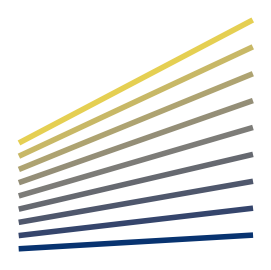

In [ ]:
##-Get the rgb values from a given color map
##-"cividis" is colorblind safe but somewhat ugly
##-List of color maps: https://matplotlib.org/stable/tutorials/colors/colormaps.html
cmap = mpl.colormaps.get_cmap('cividis')
colors=[]

N = 10
for i in range(1,N):
  colors.append(cmap(i/N))

plt.figure()

##-Set your palette as the color wheel
fig, ax = plt.subplots()

ax.set_prop_cycle(color=colors)

x = np.linspace(0, 1, 10)
for i in range(1, 10):
  plt.plot(x, i*x+i)

plt.axis('off')

plt.show()

<Figure size 324.803x324.803 with 0 Axes>

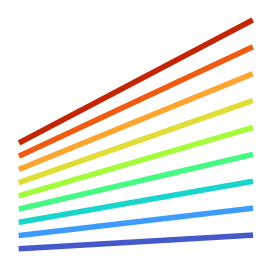

In [ ]:
##-Get the rgb values from a given color map
##-"cividis" is colorblind safe but somewhat ugly
##-https://research.google/blog/turbo-an-improved-rainbow-colormap-for-visualization/
cmap = mpl.colormaps.get_cmap('turbo')
colors=[]

N = 10
for i in range(1,N):
  colors.append(cmap(i/N))

plt.figure()

##-Set your palette as the color wheel
fig, ax = plt.subplots()
ax.set_prop_cycle(color=colors)

x = np.linspace(0, 1, 10)
for i in range(1, 10):
  plt.plot(x, i*x+i)

plt.axis('off')

plt.show()

Manually redefine the rainbow color palette with colorblind safe colors and make it a color wheel.

<Figure size 324.803x324.803 with 0 Axes>

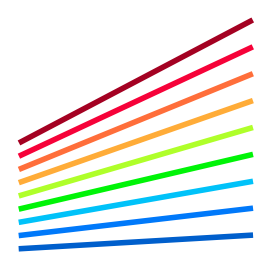

In [ ]:
##-Colors from http://mkweb.bcgsc.ca/colorblind/palettes.mhtml (by Krzywinski)
#        dark red    red      orange    yellow    green   darkgreen lightblue   blue     darkblue
colors=['#A40122','#F60239','#FF6E3A','#FFAC38','#AFFF2A','#00F407','#00C2F9','#0079FA','#005FCC']
colors.reverse()

plt.figure()

##-Set your palette as the color wheel
fig, ax = plt.subplots()
ax.set_prop_cycle(color=colors)

x = np.linspace(0, 1, 10)
for i in range(1, 10):
  plt.plot(x, i*x+i)

plt.axis('off')

plt.show()

Same but with a set from another source.

<Figure size 324.803x324.803 with 0 Axes>

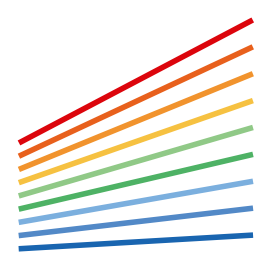

In [ ]:
##-Colors from http://cran.r-project.org/web/packages/khroma/vignettes/tol.html (by Tol)
#      dark blue    blue   light blue dark green  green    yellow    orange      red    dark red
colors=['#1965B0','#5289C7','#7BAFDE','#4EB265','#90C987','#F6C141','#F1932D','#E8601C','#DC050C']

plt.figure()

##-Set your palette as the color wheel
fig, ax = plt.subplots()
ax.set_prop_cycle(color=colors)

x = np.linspace(0, 1, 10)
for i in range(1, 10):
  plt.plot(x, i*x+i)

plt.axis('off')

plt.show()

Same but in automatic way with tol_colors.

/tmp/ipykernel_2162/2154094625.py:4: DeprecationWarning: tol_cmap is soft-deprecated since 2.0, please use tol_colors.colormaps, tol_colors.rainbow_discrete instead
  cmap = tc.tol_cmap('sunset')


<Figure size 324.803x324.803 with 0 Axes>

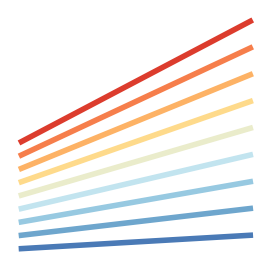

In [ ]:
##-Get the rgb values from a given color map
##-See https://personal.sron.nl/~pault/ (by Tol)
##-The 'sunset' is colorblind safe and divergent.
cmap = tc.tol_cmap('sunset')
colors=[]

N = 10
for i in range(1,N):
  colors.append(cmap(i/N))

plt.figure()

##-Set your palette as the color wheel
fig, ax = plt.subplots()
ax.set_prop_cycle(color=colors)

x = np.linspace(0, 1, 10)
for i in range(1, 10):
  plt.plot(x, i*x+i)

plt.axis('off')

plt.show()

/tmp/ipykernel_2162/3366793374.py:32: DeprecationWarning: tol_cmap is soft-deprecated since 2.0, please use tol_colors.colormaps, tol_colors.rainbow_discrete instead
  cmap4 = tc.tol_cmap('sunset') # try sunset, nightfall, BuRd


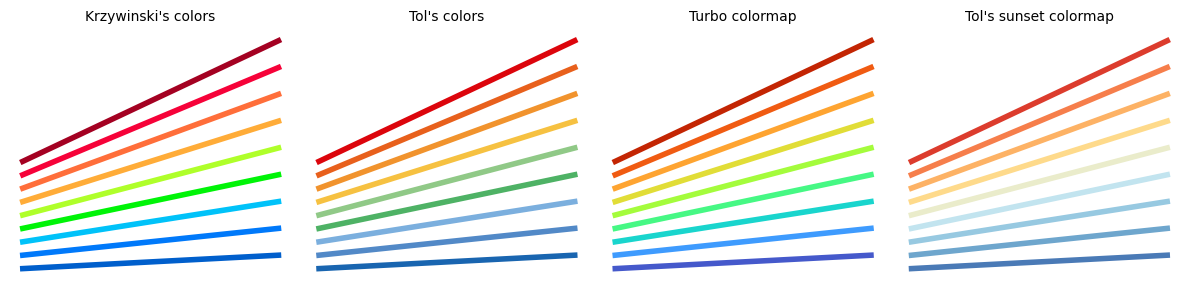

In [ ]:
fig, axs = plt.subplots(1, 4, figsize=(12, 3))

#########################
##-Krzywinski's colors-##
#########################

#         dark red      red     orange    yellow     green  darkgreen lightblue    blue     darkblue
colors1 = ['#A40122','#F60239','#FF6E3A','#FFAC38','#AFFF2A','#00F407','#00C2F9','#0079FA','#005FCC']
colors1.reverse()
axs[0].set_prop_cycle(color=colors1)

for i in range(1, 10):
  axs[0].plot(x, i*x+i)

axs[0].axis('off')

axs[0].set_title("Krzywinski's colors")

##################
##-Tol's colors-##
##################

#         dark blue   blue  light blue dark green  green    yellow    orange      red     dark red
colors2=['#1965B0','#5289C7','#7BAFDE','#4EB265','#90C987','#F6C141','#F1932D','#E8601C','#DC050C']

axs[1].set_prop_cycle(color=colors2)
for i in range(1, 10):
  axs[1].plot(x, i*x+i)

axs[1].axis('off')

axs[1].set_title("Tol's colors")

####################
##-Turbo colormap-##
####################

cmap3 = mpl.colormaps.get_cmap('turbo') ##-try rainbow, yet, turbo
colors3 = [cmap3(i/10) for i in range(1, 10)]
axs[2].set_prop_cycle(color=colors3)

for i in range(1, 10):
  axs[2].plot(x, i*x+i)

axs[2].axis('off')

axs[2].set_title("Turbo colormap")

###########################
##-Tol's sunset colormap-##
###########################

cmap4 = tc.tol_cmap('sunset') ##-try sunset, nightfall, BuRd
colors4 = [cmap4(i/10) for i in range(1, 10)]

axs[3].set_prop_cycle(color=colors4)

for i in range(1, 10):
  axs[3].plot(x, i*x+i)

axs[3].axis('off')

axs[3].set_title("Tol's sunset colormap")

plt.tight_layout()
plt.show()

## Colorblind-safe color palettes

Simulate the colorblind view. Options for "colorblind_type" are:

        * 'Normal': Normal vision
        * 'Protanopia': Red-green colorblindness (1% males)
        * 'Protanomaly': Red-green colorblindness (1% males, 0.01% females)
        * 'Deuteranopia': Red-green colorblindness (1% males)
        * 'Deuteranomaly': Red-green colorblindness (most common type: 6% males,0.4% females)
        * 'Tritanopia': Blue-yellow colourblindness (<1% males and females)
        * 'Tritanomaly' Blue-yellow colourblindness (0.01% males and females)
        * 'Achromatopsia': Total colourblindness
        * 'Achromatomaly': Total colourblindness

/tmp/ipykernel_2162/1732557602.py:41: DeprecationWarning: tol_cmap is soft-deprecated since 2.0, please use tol_colors.colormaps, tol_colors.rainbow_discrete instead
  cmap4 = tc.tol_cmap('sunset') # try sunset, nightfall, BuRd


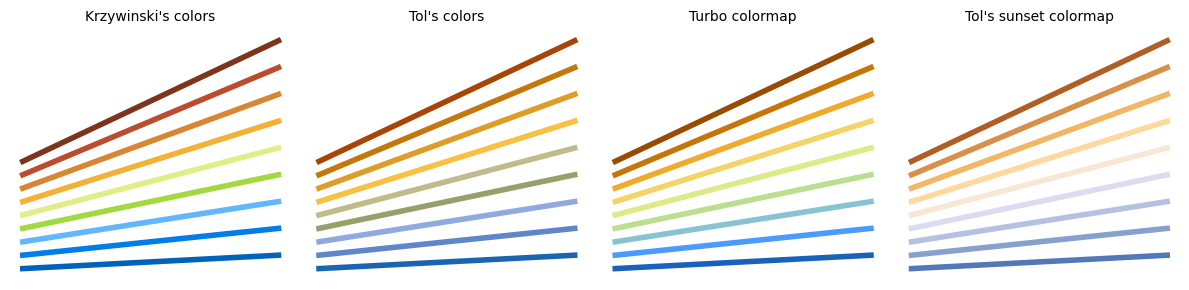

In [ ]:
fig, axs = plt.subplots(1, 4, figsize=(12, 3))

##-Try different colorblind types
colorblindness = 'Deuteranomaly'

#########################
##-Krzywinski's colors-##
#########################

#         dark red      red     orange    yellow     green  darkgreen lightblue    blue     darkblue
colors1 = ['#A40122','#F60239','#FF6E3A','#FFAC38','#AFFF2A','#00F407','#00C2F9','#0079FA','#005FCC']
colors1.reverse()

colors_rgb1 = [mpl.colors.to_rgb(i) for i in colors1]
colors_sim1 = [dis.colorblind.colorblind_filter(i, colorblind_type=colorblindness) for i in colors_rgb1]
axs[0].set_prop_cycle(color=colors_sim1)

for i in range(1, 10):
  axs[0].plot(x, i*x+i)

axs[0].axis('off')

axs[0].set_title("Krzywinski's colors")

##################
##-Tol's colors-##
##################

#         dark blue   blue  light blue dark green  green    yellow    orange      red     dark red
colors2=['#1965B0','#5289C7','#7BAFDE','#4EB265','#90C987','#F6C141','#F1932D','#E8601C','#DC050C']

colors_rgb2 = [mpl.colors.to_rgb(i) for i in colors2]
colors_sim2 = [dis.colorblind.colorblind_filter(i, colorblind_type=colorblindness) for i in colors_rgb2]
axs[1].set_prop_cycle(color=colors_sim2)

for i in range(1, 10):
  axs[1].plot(x, i*x+i)

axs[1].axis('off')

axs[1].set_title("Tol's colors")

####################
##-Turbo colormap-##
####################

cmap3 = mpl.colormaps.get_cmap('turbo') ##-try rainbow, yet, turbo
colors3 = [cmap3(i/10) for i in range(1, 10)]

colors_rgb3 = [mpl.colors.to_rgb(i) for i in colors3]
colors_sim3 = [dis.colorblind.colorblind_filter(i, colorblind_type=colorblindness) for i in colors_rgb3]
axs[2].set_prop_cycle(color=colors_sim3)

for i in range(1, 10):
  axs[2].plot(x, i*x+i)

axs[2].axis('off')

axs[2].set_title("Turbo colormap")

###########################
##-Tol's sunset colormap-##
###########################

cmap4 = tc.tol_cmap('sunset') ##-try sunset, nightfall, BuRd
colors4 = [cmap4(i/10) for i in range(1, 10)]

colors_rgb4 = [mpl.colors.to_rgb(i) for i in colors4]
colors_sim4 = [dis.colorblind.colorblind_filter(i, colorblind_type=colorblindness) for i in colors_rgb4]
axs[3].set_prop_cycle(color=colors_sim4)

for i in range(1, 10):
  axs[3].plot(x, i*x+i)

axs[3].axis('off')

axs[3].set_title("Tol's sunset colormap")

plt.tight_layout()
plt.show()

Show the plot in grayscale.

/tmp/ipykernel_2162/1367492001.py:46: DeprecationWarning: tol_cmap is soft-deprecated since 2.0, please use tol_colors.colormaps, tol_colors.rainbow_discrete instead
  cmap4 = tc.tol_cmap('sunset')


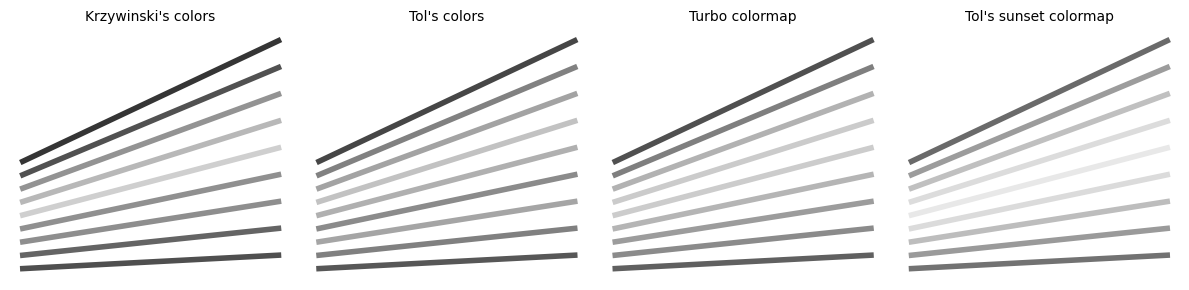

In [ ]:
fig, axs = plt.subplots(1, 4, figsize=(12, 3))

##-Function to convert colors to grayscale
def to_grayscale(colors_rgb):
  colors_bgw = []
  for i in colors_rgb:
    gray = 0.299*i[0] + 0.587*i[1] + 0.114*i[2]  ##-Luminosity method
    colors_bgw.append((gray, gray, gray))
  return colors_bgw

x = np.linspace(0, 1, 10)

#########################
##-Krzywinski's colors-##
#########################

colors1 = ['#A40122','#F60239','#FF6E3A','#FFAC38','#AFFF2A','#00F407','#00C2F9','#0079FA','#005FCC']
colors1.reverse()

colors_rgb1 = [mpl.colors.to_rgb(i) for i in colors1]
colors_bgw1 = to_grayscale(colors_rgb1)
axs[0].set_prop_cycle(color=colors_bgw1)

for i in range(1, 10):
  axs[0].plot(x, i*x+i)

axs[0].axis('off')

axs[0].set_title("Krzywinski's colors")

##################
##-Tol's colors-##
##################

colors2 = ['#1965B0','#5289C7','#7BAFDE','#4EB265','#90C987','#F6C141','#F1932D','#E8601C','#DC050C']

colors_rgb2 = [mpl.colors.to_rgb(i) for i in colors2]
colors_bgw2 = to_grayscale(colors_rgb2)
axs[1].set_prop_cycle(color=colors_bgw2)

for i in range(1, 10):
  axs[1].plot(x, i*x+i)

axs[1].axis('off')

axs[1].set_title("Tol's colors")

####################
##-Turbo colormap-##
####################

cmap3 = mpl.colormaps.get_cmap('turbo')
colors3 = [cmap3(i/10) for i in range(1, 10)]

colors_rgb3 = [mpl.colors.to_rgb(i) for i in colors3]
colors_bgw3 = to_grayscale(colors_rgb3)
axs[2].set_prop_cycle(color=colors_bgw3)

for i in range(1, 10):
  axs[2].plot(x, i*x+i)

axs[2].axis('off')

axs[2].set_title("Turbo colormap")

###########################
##-Tol's sunset colormap-##
###########################

cmap4 = tc.tol_cmap('sunset')
colors4 = [cmap4(i/10) for i in range(1, 10)]

colors_rgb4 = [mpl.colors.to_rgb(i) for i in colors4]
colors_bgw4 = to_grayscale(colors_rgb4)
axs[3].set_prop_cycle(color=colors_bgw4)

for i in range(1, 10):
  axs[3].plot(x, i*x+i)

axs[3].axis('off')

axs[3].set_title("Tol's sunset colormap")

plt.tight_layout()
plt.show()

Some reading:

Find "Rainbow Colormaps: What are they good and bad for?"

Find "Rainbow Colormaps Are Not All Bad"

Find "Why the Rainbow Color Map is Problematic"

Find "Why We Use Bad Color Maps and What You Can Do About It"

Find "What is the biggest problem of the Jet and Rainbow color maps, and why is it not as evil as I thought?"

## Summary

After completing this notebook, you should be able to:

1. Set figure size, DPI, line width, font family, and font sizes for axes, ticks, and legends globally with plt.rc(), so every figure in a notebook inherits consistent formatting without repeated boilerplate.
2. Apply colorblind-safe palettes. Switch matplotlib's default color cycle to tableau-colorblind10 or seaborn-v0_8-colorblind with a single plt.style.use() call, and generate maximally perceptually distinct color sets of arbitrary length using distinctipy.
3. Sample continuous colormaps for discrete use. Extract N evenly spaced RGBA values from any matplotlib colormap (cividis, turbo) or from Tol's specialized scientific colormaps (sunset, nightfall, BuRd) using tol_colors, and assign them as a custom color cycle with ax.set_prop_cycle().
4. Apply the Krzywinski and Tol hand-picked sequences, which cover the full hue range in a perceptually ordered and colorblind-robust way, as alternatives to matplotlib's default rainbow or jet.
5. Simulate colorblindness. Use distinctipy.colorblind.colorblind_filter() to transform any RGB palette through nine colorblindness models, from the most common (Deuteranomaly, affecting around 6% of males) to total achromatopsia, and compare palettes side by side under each condition.
6. Check grayscale robustness. Apply the luminosity-weighted grayscale conversion (0.299R + 0.587G + 0.114B) to any palette and plot the result, verifying that lines remain distinguishable when printed in black and white.